Librerias

In [1]:
import numpy as np # Arreglos
import pandas as pd # Excel con esteroides

import matplotlib.pyplot as plt # Geogebra con esteroides

import glob # Buscar archivos
import gc # Recolector de basura

from scipy.stats import ks_2samp # Prueba de Kolmogorov-Smirnov

from sklearn.preprocessing import MinMaxScaler # Normalizar datos
from sklearn.cluster import KMeans # KMeans
from sklearn.utils import resample # Submuestreo

Buscar CSV's

In [52]:
# Buscar el nombre del archivo CSV

archivos = glob.glob("*.csv")
print("Todos los archivos CSV en la carpeta:", len(archivos)) 

Todos los archivos CSV en la carpeta: 182


Ver diferencias entre las columnas

In [53]:
# Leer las columnas de los archivos CSV

columnas_csv = []

for archivo in archivos:
    df = pd.read_csv(archivo, nrows=0)
    columnas_csv.append(df.columns.tolist())

# Comparar las columnas diferentes entre los archivos CSV

columnas_diferentes = set(columnas_csv[0])

for columnas in columnas_csv[1:]:
    columnas_diferentes = columnas_diferentes.symmetric_difference(set(columnas))

# Mostrar las columnas diferentes entre los archivos CSV
print("Columnas diferentes entre los archivos CSV:")
for columna in columnas_diferentes:
    print(columna)

Columnas diferentes entre los archivos CSV:
Fecha_Retiro
Hora_retiro
Fecha_retiro
Ciclo_Estacion_Arribo
Edad_Usuario
Hora_Arribo
Fecha_arribo
CE_arribo
Ciclo_Estacion_Retiro
Fecha Arribo
Edad_usuario
Hora_Retiro
Hora_arribo
BikeID
Genero_usuario
Unnamed: 9
Hora Arribo
Genero_Usuario
Hora_Retiro.1
CE_retiro


In [54]:
# Nombre de las columnas

columnas = [
    'Genero',
    'Edad',
    'Bicicleta',
    'F_Retiro',
    'H_Retiro',
    'CER',
    'F_Arribo',
    'H_Arribo',
    'CEA'   
]

In [55]:
# Correcciones de nombres de columnas

correcciones = {
    'Fecha Arribo' : 'F_Arribo',
    'Hora_retiro' : 'H_Retiro',
    'Ciclo_EstacionArribo' : 'CEA',
    'Hora_arribo' : 'H_Arribo',
    'Fecha_arribo' : 'F_Arribo',
    'Fecha_retiro' : 'F_Retiro',
    'Hora Arribo' : 'H_Arribo',
    'Genero_usuario' : 'Genero',
    'CE_retiro' : 'CER',
    'Edad_usuario' : 'Edad',
    'CE_arribo' : 'CEA',
    'Hora_Retiro.1' : 'H_Arribo',
    'Genero_Usuario' : 'Genero',
    'Edad_Usuario' : 'Edad',
    'Ciclo_Estacion_Arribo' : 'CEA',
    'Fecha_Arribo' : 'F_Arribo',
    'Hora_Arribo' : 'H_Arribo',
    'Ciclo_Estacion_Retiro' : 'CER',
    'Fecha_Retiro' : 'F_Retiro',
    'Hora_Retiro' : 'H_Retiro',
    'Bici' : 'Bicicleta'
}

Listas y maperos que ayudaran con la limpieza

In [56]:
# Apoyo para el cambio de fechas

años = ['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', 
        '2021', '2022', '2023', '2024', '2025']
meses = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
dias = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', 
        '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31']
horas = ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14',
         '15', '16', '17', '18', '19', '20', '21', '22', '23']
minutos = ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', 
        '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30',
        '31', '32', '33', '34', '35', '36', '37', '38','39', '40', '41', '42', '43', '44', '45',
        '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59']
segundos = ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', 
            '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', 
            '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59']


In [57]:
# Convertir el genero a un número
# 0 = Masculino, 1 = Femenino, 2 = Otro, 3 = Desconocido
mapa = {'M': 0, 'F': 1, 'O': 2, '?': 3}

Funcion fecha que ayuda a identificar de manera correcta para cada caso la fecha correcta en todos los CSV's

In [58]:
# Formatear las fechas

def fechas(fecha, ms, añ):
    # Formato: 2025-05-12 22:34:34

    # 18: 2010-02-18 8:00:47
    # 19: 2010-02-18 08:00:47
    # 26: 2010-02-18 08:00:47.000000
    # 15: Eliminar
    # 17: 30/08/22 07:31:24

    fecha = str(fecha).strip()
    tamaño = len(fecha)

    if tamaño  in [18, 21, 22]:
        fecha = fecha[0:19]

    fecha = fecha.strip()
    tamaño = len(fecha)

    if tamaño == 18:
        fecha = fecha[:11] + '0' + fecha[11:]
    
    if tamaño == 15:
        if fecha[14] == ':':
            return None
        return 0
    
    if tamaño == 17:
        fecha = fecha[:6] + '20' + fecha[6:]

    if fecha[:4].isdigit():
        año = fecha[0:4]
        mes = fecha[5:7]
        dia = fecha[8:10]
        hora = fecha[11:13]
        minuto = fecha[14:16]
        segundo = fecha[17:19]
    
    elif fecha[:2].isdigit():
        año = fecha[6:10]
        mes = fecha[3:5]
        dia = fecha[0:2]
        hora = fecha[11:13]
        minuto = fecha[14:16]
        segundo = fecha[17:19]
        
    else:
        print("Error en la fecha: ", fecha)
        return None
    
    if ms != '0':
        if ms != mes:
            print("No coincide el mes con la fechga del CSV: ", fecha)
            return None
        if añ != año:
            print("No coincide el año con la fecha del CSV: ", fecha)
            return None
    
    if año not in años:
        print("Error en el año: ", fecha)
        return None
    
    if mes not in meses:
        print("Error en el mes: ", fecha)
        return None
    
    if dia not in dias:
        print("Error en el dia: ", fecha)
        return None
    
    if hora not in horas:
        print("Error en la hora: ", fecha)
        return None
    
    if minuto not in minutos:
        print("Error en el minuto: ", fecha)
        return None
    
    if segundo not in segundos:
        print("Error en el segundo: ", fecha)
        return None
    
    return año + '-' + mes + '-' + dia + ' ' + hora + ':' + minuto + ':' + segundo

La funcion limpieza ayuda a dar una pirmera limpieza genera a todo el df. En este se verifican si los valores que deberan estar en cada coluimna son los correctos asi como tambien para la fecha. yYa limpirado los datos se generan el tipo correcto de datos para cada uno para hacer que el df sea lo mas pequeño posible

In [66]:
# Cambia columnas, tipo de datos, elimina columnas innecesarias etc...

def limpieza(nombre):

    # Año y mes del archivo
    año = str(nombre.split("-")[0])
    mes = str(nombre.split("-")[1].split(".")[0])

    # Leer el archivo CSV
    df = pd.read_csv(nombre, dtype = str)
    t1 = len(df)

    # Imprimir el nombre del archivo CSV
    print("Archivo: ", nombre)

    # Borrar columnas extras
    df.drop(['BikeID', 'Unnamed: 9'],inplace=True, axis=1, errors='ignore')

    # Cambiar los nombres de las columnas
    df.rename(columns = correcciones, inplace=True)

    # Ordenar las columnas
    df = df[columnas]

    # Borrar datos nulos excepto en genero
    col_sg = df.columns[df.columns != 'Genero']
    df = df.dropna(subset=col_sg)
    
    #Tipos de datos

    #Edad
    df['Edad'] = df['Edad'].astype('uint8')

    # Bicicleta
    df['Bicicleta'] = pd.to_numeric(df['Bicicleta'], errors='coerce')
    df = df.dropna(subset=['Bicicleta'])
    df['Bicicleta'] = df['Bicicleta'].astype('uint32')

    # Estaciones
    df['CER'] = pd.to_numeric(df['CER'], errors='coerce')
    df = df.dropna(subset=['CER'])
    df['CER'] = df['CER'].astype('uint16')

    df['CEA'] = pd.to_numeric(df['CEA'], errors='coerce')
    df = df.dropna(subset=['CEA'])
    df['CEA'] = df['CEA'].astype('uint16')

    # Fechas
    df['F_Retiro'] = df['F_Retiro'].astype(str).str.strip() + ' ' + df['H_Retiro'].astype(str).str.strip()
    df['F_Arribo'] = df['F_Arribo'].astype(str).str.strip() + ' ' + df['H_Arribo'].astype(str).str.strip()

    df = df.drop(['H_Retiro', 'H_Arribo'], axis=1)

    df['F_Retiro'] = df['F_Retiro'].apply(lambda x: fechas(x, '0', '0'))
    df['F_Arribo'] = df['F_Arribo'].apply(lambda x: fechas(x, mes, año))

    df['F_Retiro'] = pd.to_datetime(df['F_Retiro'], errors='coerce')
    df['F_Arribo'] = pd.to_datetime(df['F_Arribo'], errors='coerce')
    df = df.dropna(subset=['F_Retiro', 'F_Arribo'])

    #Genero
    df['Genero'] = df['Genero'].map(mapa)

    # Verificar la cantidad de datos eliminados
    t2 = len(df)
    if t2/t1 < 0.95:
        print("El porcentaje de datos es: ", (t2/t1) * 100,"%")

    # Guardar el arcivo en parquet
    name = nombre.split(".")[0]
    name = name + ".parquet"
    df.to_parquet(name, index=False, engine='pyarrow', compression='gzip')
    
    #Eliminar el dataframe
    del df

    return(t1, t2)

Limpiar y generar todos los nuevos archivos .parquet

In [67]:
# Limpiar los archivos CSV
total = 0
total_borrado = 0

for nombre in archivos:
    t1, t2 = limpieza(nombre)
    total += t1
    total_borrado += (t1 - t2)


Archivo:  2010-02.csv
Archivo:  2010-03.csv
Archivo:  2010-04.csv
Archivo:  2010-05.csv
Archivo:  2010-06.csv
Archivo:  2010-07.csv
Archivo:  2010-08.csv
Archivo:  2010-09.csv
Archivo:  2010-10.csv
Archivo:  2010-11.csv
Archivo:  2010-12.csv
Archivo:  2011-01.csv
Archivo:  2011-02.csv
Archivo:  2011-03.csv
Archivo:  2011-04.csv
Archivo:  2011-05.csv
Archivo:  2011-06.csv
Archivo:  2011-07.csv
Archivo:  2011-08.csv
Archivo:  2011-09.csv
Archivo:  2011-10.csv
Archivo:  2011-11.csv
Archivo:  2011-12.csv
Archivo:  2012-01.csv
Archivo:  2012-02.csv
Archivo:  2012-03.csv
Archivo:  2012-04.csv
Archivo:  2012-05.csv
Archivo:  2012-06.csv
Archivo:  2012-07.csv
Archivo:  2012-08.csv
Archivo:  2012-09.csv
Archivo:  2012-10.csv
Archivo:  2012-11.csv
Archivo:  2012-12.csv
Archivo:  2013-01.csv
Archivo:  2013-02.csv
Archivo:  2013-03.csv
Archivo:  2013-04.csv
Archivo:  2013-05.csv
Archivo:  2013-06.csv
Archivo:  2013-07.csv
Archivo:  2013-08.csv
Archivo:  2013-09.csv
Archivo:  2013-10.csv
Archivo:  

Cantidad de datos eliminados

In [68]:
# Ver la cantidad de datos eliminados

print("Total de datos: ", total)
print("Total de datos borrados: ", total_borrado)
print("Porcentaje de datos borrados: ", (total_borrado/total) * 100, "%")

Total de datos:  118665631
Total de datos borrados:  3875186
Porcentaje de datos borrados:  3.265634680693688 %


In [69]:
# Buscar los archivos parquet
archivos_parquet = glob.glob("*.parquet")
print("Archivos parquet: ", len(archivos_parquet))

Archivos parquet:  182


En la limpieza no se vieron los datos que habian en el genero, ahora se vera de manera detallada ya que en el porgrama ecobici durante el tiempo que ha estado no siempre estuvo el genero neutro por lo que se tiene que verificar en que csv aplic y en cuales no

In [70]:
# Ver los valores unicos de genero

for archivo in archivos_parquet:
    df = pd.read_parquet(archivo, engine='pyarrow', columns=['Genero'])
    print("Archivo: ", archivo)
    print(df['Genero'].unique())

Archivo:  2010-02.parquet
[0 1]
Archivo:  2010-03.parquet
[0 1]
Archivo:  2010-04.parquet
[0 1]
Archivo:  2010-05.parquet
[0 1]
Archivo:  2010-06.parquet
[0 1]
Archivo:  2010-07.parquet
[1 0]
Archivo:  2010-08.parquet
[0 1]
Archivo:  2010-09.parquet
[0 1]
Archivo:  2010-10.parquet
[1 0]
Archivo:  2010-11.parquet
[0 1]
Archivo:  2010-12.parquet
[0 1]
Archivo:  2011-01.parquet
[0 1]
Archivo:  2011-02.parquet
[0 1]
Archivo:  2011-03.parquet
[0 1]
Archivo:  2011-04.parquet
[0 1]
Archivo:  2011-05.parquet
[0 1]
Archivo:  2011-06.parquet
[1 0]
Archivo:  2011-07.parquet
[0 1]
Archivo:  2011-08.parquet
[0 1]
Archivo:  2011-09.parquet
[0 1]
Archivo:  2011-10.parquet
[1 0]
Archivo:  2011-11.parquet
[0 1]
Archivo:  2011-12.parquet
[0 1]
Archivo:  2012-01.parquet
[0 1]
Archivo:  2012-02.parquet
[0 1]
Archivo:  2012-03.parquet
[1 0]
Archivo:  2012-04.parquet
[0 1]
Archivo:  2012-05.parquet
[1 0]
Archivo:  2012-06.parquet
[1 0]
Archivo:  2012-07.parquet
[0 1]
Archivo:  2012-08.parquet
[0 1]
Archivo:

In [72]:
# Ver cuantos filas nulas hay en los archivos parquet
# Estos datos corrsponden a datos que no se pudieron limpiar o que no se pueden limpiar

aux = ['2013-02.parquet','2013-03.parquet']

df1 = pd.read_parquet(aux[0], engine='pyarrow')
df2 = pd.read_parquet(aux[1], engine='pyarrow')

print("Archivo 1: ", df1.isna().sum())
print("Archivo 2: ", df2.isna().sum())

# Eliminar las filas nulas

df1 = df1.dropna()
df2 = df2.dropna()

# Guardar los archivos parquet sin filas nulas

df1.to_parquet("2013-02.parquet", index=False, engine='pyarrow', compression='gzip')
df2.to_parquet("2013-03.parquet", index=False, engine='pyarrow', compression='gzip')

Archivo 1:  Genero       9
Edad         0
Bicicleta    0
F_Retiro     0
CER          0
F_Arribo     0
CEA          0
dtype: int64
Archivo 2:  Genero       34
Edad          0
Bicicleta     0
F_Retiro      0
CER           0
F_Arribo      0
CEA           0
dtype: int64


In [73]:
#Verificar los archivos parquet con filas nulas en la columna genero
# Esstos arhivos corresponden a datos nulos que no se habian categorizado bien
# Correspondena cuando ecobici agrego el genero neutro y no habain elegido un  nuevo valor
vacios = []

for archivo in archivos_parquet:
    df = pd.read_parquet(archivo, engine='pyarrow', columns=['Genero'])
    if df['Genero'].isna().sum() > 0:
        vacios.append(archivo)

# Imputar los valores nulos de genero
# 0 = Masculino, 1 = Femenino, 2 = Otro, 3 = Desconocido

for archivo in vacios:
    df = pd.read_parquet(archivo, engine='pyarrow')
    df['Genero'] = df['Genero'].fillna(2)
    df.to_parquet(archivo, index=False, engine='pyarrow', compression='gzip')


Unificar los archivos

In [74]:
# Unir los archivos parquet para unificar todos los datos
dfs = []

for archivo in archivos_parquet:
    print("Archivo: ", archivo)
    df = pd.read_parquet(archivo)
    dfs.append(df)

df_completo = pd.concat(dfs, ignore_index=True)
df_completo.to_parquet("Ecobici.parquet", engine='pyarrow')

print("Archivo: ecobici.parquet")
print("Total de datos: ", len(df_completo))

Archivo:  2010-02.parquet
Archivo:  2010-03.parquet
Archivo:  2010-04.parquet
Archivo:  2010-05.parquet
Archivo:  2010-06.parquet
Archivo:  2010-07.parquet
Archivo:  2010-08.parquet
Archivo:  2010-09.parquet
Archivo:  2010-10.parquet
Archivo:  2010-11.parquet
Archivo:  2010-12.parquet
Archivo:  2011-01.parquet
Archivo:  2011-02.parquet
Archivo:  2011-03.parquet
Archivo:  2011-04.parquet
Archivo:  2011-05.parquet
Archivo:  2011-06.parquet
Archivo:  2011-07.parquet
Archivo:  2011-08.parquet
Archivo:  2011-09.parquet
Archivo:  2011-10.parquet
Archivo:  2011-11.parquet
Archivo:  2011-12.parquet
Archivo:  2012-01.parquet
Archivo:  2012-02.parquet
Archivo:  2012-03.parquet
Archivo:  2012-04.parquet
Archivo:  2012-05.parquet
Archivo:  2012-06.parquet
Archivo:  2012-07.parquet
Archivo:  2012-08.parquet
Archivo:  2012-09.parquet
Archivo:  2012-10.parquet
Archivo:  2012-11.parquet
Archivo:  2012-12.parquet
Archivo:  2013-01.parquet
Archivo:  2013-02.parquet
Archivo:  2013-03.parquet
Archivo:  20

In [75]:
# Vaciar memoria
del dfs, df_completo

In [76]:
# Leer el archivo completo
df = pd.read_parquet("Ecobici.parquet")

In [79]:
print(df['Genero'].unique())
df['Genero'] = df['Genero'].astype('category')

print(df.info())

[0. 1. 2. 3.]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114790402 entries, 0 to 114790401
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Genero     category      
 1   Edad       uint8         
 2   Bicicleta  uint32        
 3   F_Retiro   datetime64[ns]
 4   CER        uint16        
 5   F_Arribo   datetime64[ns]
 6   CEA        uint16        
dtypes: category(1), datetime64[ns](2), uint16(2), uint32(1), uint8(1)
memory usage: 2.8 GB
None


In [80]:
df.to_parquet("Ecobici.parquet", engine='pyarrow')

In [12]:
# Borrar el dataframe
del df

Limpiar los datos a partir de verificar que datos osn atipicos o que datos son incorrectos y no pueden ser verdaderos en el df

In [2]:
# Leer el archivo completo
df = pd.read_parquet("Ecobici.parquet")
df.head(10)

,Genero,Edad,Bicicleta,F_Retiro,CER,F_Arribo,CEA
0,0.0,28,69,2010-02-16 12:42:32,85,2010-02-16 12:45:37,85
1,0.0,30,11,2010-02-16 12:53:29,85,2010-02-16 13:22:23,26
2,0.0,37,43,2010-02-16 13:21:46,85,2010-02-16 13:49:47,13
3,0.0,37,826,2010-02-16 14:06:40,22,2010-02-16 14:23:13,85
4,0.0,19,662,2010-02-16 15:31:15,27,2010-02-16 16:29:17,74
5,1.0,25,8,2010-02-16 16:31:53,85,2010-02-16 16:49:26,20
6,1.0,31,5,2010-02-16 16:33:25,85,2010-02-16 16:49:28,20
7,0.0,28,680,2010-02-16 17:06:18,20,2010-02-16 17:22:56,25
8,0.0,28,618,2010-02-16 17:30:14,20,2010-02-16 17:48:24,17
9,0.0,32,812,2010-02-16 18:10:21,49,2010-02-16 18:16:21,72


In [3]:
# Edad
# Por reglas del programa ecobici, no se permiten menores de 16 años

df = df[df['Edad'] > 16]

# Es posible ser de la tercera edad y andar en bicicleta pero tampoco tanto
df = df[df['Edad'] <80 ]

In [4]:
# Bicicleta

q1 = df['Bicicleta'].quantile(0.25)
q3 = df['Bicicleta'].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

out = df[(df['Bicicleta'] < limite_inferior) | (df['Bicicleta'] > limite_superior)]

print('Datos totales: ', len(df)) 
print('Datos fuera de rango: ', len(out))
print('Porcentage de datos fuera de rango: ', (len(out)/len(df)) * 100, '%')

df = df[(df['Bicicleta'] >= limite_inferior) & (df['Bicicleta'] <= limite_superior)]

Datos totales:  114712061
Datos fuera de rango:  445844
Porcentage de datos fuera de rango:  0.3886635774070871 %


In [5]:
# CER
# En el sistema ecobici hay actualmente alrededor de 700 estaciones habiliatadas sin contar las que en algun momento fueron cerradas
# Se borrar las que esten arriba de 711

df = df[df['CER'] < 712]    

In [6]:
# CEA
# En el sistema ecobici hay actualmente alrededor de 700 estaciones habiliatadas sin contar las que en algun momento fueron cerradas
# Se borrar las que esten arriba de 711

df = df[df['CEA'] < 712]

In [7]:
# Guardar el archivo parquet
df.to_parquet("Ecobici.parquet", engine='pyarrow')
del df

Aplicar un MinMaxScaler para los datos y guardarlos en un nuevo parquet para con este generar los modelos

In [9]:
df = pd.read_parquet("Ecobici.parquet")

In [12]:
fechas = df[['F_Retiro', 'F_Arribo']]
X = df[['Genero', 'Edad', 'Bicicleta', 'CER', 'CEA']]

In [ ]:
# Escala primero los datos, solo una vez
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # ajusta columnas

In [20]:
df_escalado = pd.DataFrame(X_scaled, columns=X.columns)
df_escalado.to_parquet("X.parquet", engine='pyarrow')

In [6]:
X = pd.read_parquet("X.parquet")

Kmeans

In [4]:
def encontrar_mejor_k(X, max_k=10, muestra_frac=0.1, umbral=0.05, random_state=42):

    # Crear muestra del dataset para el cálculo de k
    n_muestra = int(len(X) * muestra_frac)
    X_sample = resample(X, n_samples=n_muestra, random_state=random_state)

    sse_lista = []
    inercia_anterior = None
    mejor_k = 2

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        kmeans.fit(X_sample)
        inercia_actual = kmeans.inertia_
        sse_lista.append(inercia_actual)

        if inercia_anterior is not None:
            mejora_relativa = abs((inercia_anterior - inercia_actual) / inercia_anterior)
            if mejora_relativa < umbral:
                mejor_k = k
                break
        
        inercia_anterior = inercia_actual

    else:
        # Si nunca se cumple la mejora mínima, se queda con el max_k
        mejor_k = max_k

    return mejor_k, sse_lista

In [7]:
k_optimo, sse = encontrar_mejor_k(X, max_k=10, muestra_frac=0.1, umbral=0.05)

print("Mejor k encontrado:", k_optimo)

Mejor k encontrado: 10


In [8]:
# Modelo Final

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans_final.fit(X)

df_modelos = pd.DataFrame({'cluster': kmeans_final.labels_})

In [9]:
df_modelos['cluster'] = df_modelos['cluster'].astype('category')
df_modelos.to_parquet("df_modelos.parquet", engine='pyarrow')

In [22]:
df_modelos = pd.read_parquet("df_modelos.parquet")
df_fechas = pd.read_parquet("df_fechas.parquet") 

In [26]:
df_modelos['F_Retiro'] = df_fechas['F_Retiro']
df_modelos['F_Arribo'] = df_fechas['F_Arribo']

In [27]:
df_modelos.to_parquet("df_modelos.parquet", engine='pyarrow')

Se perfila con respecto al tiempo.

Se toman varias perspectivas:

- Hrs del dia
- Duracion del viaje
- Dias de la semana

In [18]:
df_modelos = pd.read_parquet("df_modelos.parquet")
df_modelos.head(10)

,cluster,F_Retiro,F_Arribo
0,6,2010-02-16 12:42:32,2010-02-16 12:45:37
1,6,2010-02-16 12:53:29,2010-02-16 13:22:23
2,6,2010-02-16 13:21:46,2010-02-16 13:49:47
3,6,2010-02-16 14:06:40,2010-02-16 14:23:13
4,6,2010-02-16 15:31:15,2010-02-16 16:29:17
5,8,2010-02-16 16:31:53,2010-02-16 16:49:26
6,8,2010-02-16 16:33:25,2010-02-16 16:49:28
7,6,2010-02-16 17:06:18,2010-02-16 17:22:56
8,6,2010-02-16 17:30:14,2010-02-16 17:48:24
9,6,2010-02-16 18:10:21,2010-02-16 18:16:21


In [6]:
def franja_3_horas(hora):
    if 0 <= hora < 3:
        return '00-03'
    elif 3 <= hora < 6:
        return '03-06'
    elif 6 <= hora < 9:
        return '06-09'
    elif 9 <= hora < 12:
        return '09-12'
    elif 12 <= hora < 15:
        return '12-15'
    elif 15 <= hora < 18:
        return '15-18'
    elif 18 <= hora < 21:
        return '18-21'
    else:
        return '21-24'

# Extraemos la hora
df_modelos['hora_R'] = df_modelos['F_Retiro'].dt.hour
# Aplicamos la función para crear la categoría
df_modelos['franja_3h_R'] = df_modelos['hora_R'].apply(franja_3_horas)

df_modelos['hora_A'] = df_modelos['F_Arribo'].dt.hour
# Aplicamos la función para crear la categoría
df_modelos['franja_3h_A'] = df_modelos['hora_A'].apply(franja_3_horas)
# Convertir a tipo de dato categórico

In [10]:
perfil_R = pd.crosstab(df_modelos['hora_R'] , df_modelos['cluster'])
perfil_A = pd.crosstab(df_modelos['hora_A'] , df_modelos['cluster'])

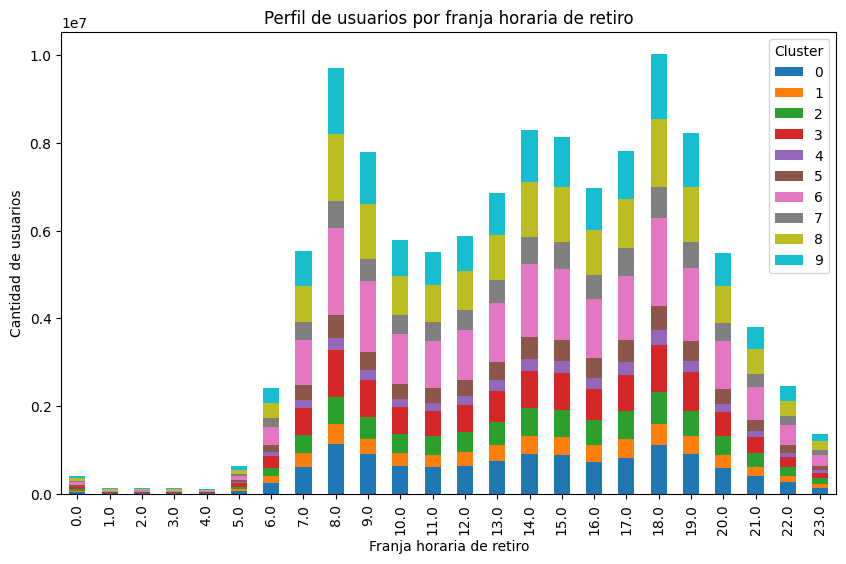

In [11]:
perfil_R.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Perfil de usuarios por franja horaria de retiro')
plt.xlabel('Franja horaria de retiro')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Cluster')
plt.show()

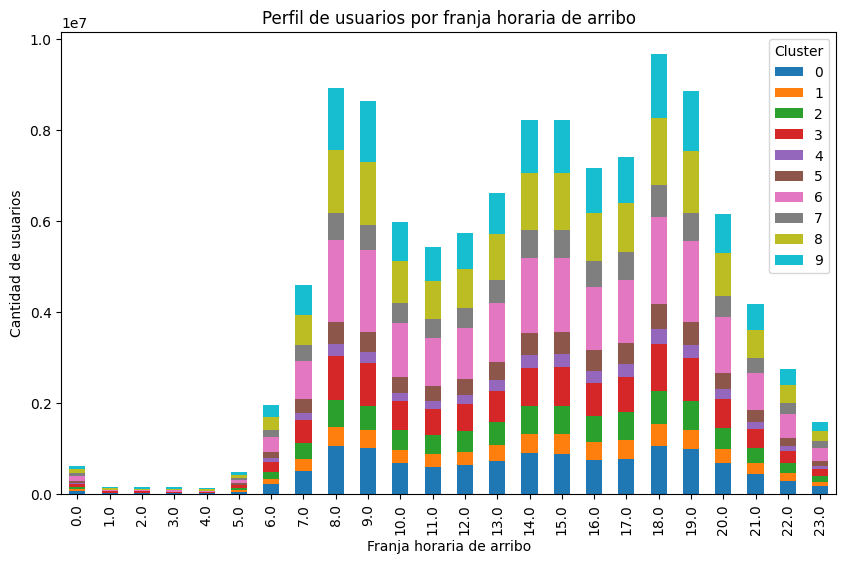

In [12]:
perfil_A.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Perfil de usuarios por franja horaria de arribo')
plt.xlabel('Franja horaria de arribo')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Cluster')
plt.show()

In [13]:
# Suponiendo que las columnas son 'F_Retiro' y 'F_Arribo' de tipo datetime
df_modelos['duracion_horas'] = (df_modelos['F_Arribo'] - df_modelos['F_Retiro']).dt.total_seconds() / 3600

In [14]:
bins = [0, 0.25, 0.5, 1, 2, df_modelos['duracion_horas'].max()]
labels = ['0-15 min', '15-30 min', '30 min - 1 h', '1-2 h', '> 2 h']

df_modelos['categoria_duracion'] = pd.cut(df_modelos['duracion_horas'], bins=bins, labels=labels, include_lowest=True)

In [15]:
perfil_duracion = pd.crosstab(df_modelos['categoria_duracion'], df_modelos['cluster'])

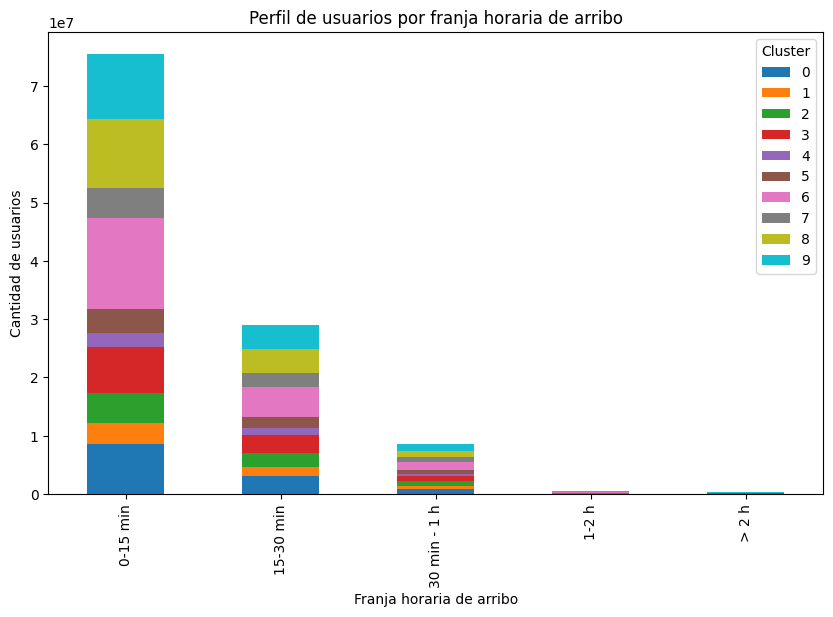

In [16]:
perfil_duracion.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Perfil de usuarios por franja horaria de arribo')
plt.xlabel('Franja horaria de arribo')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Cluster')
plt.show()

In [19]:
df_modelos['dia_semana_R'] = df_modelos['F_Retiro'].dt.day_name()

df_modelos['dia_semana_A'] = df_modelos['F_Arribo'].dt.day_name()

In [20]:
perfil_dia_R = pd.crosstab(df_modelos['dia_semana_R'] , df_modelos['cluster'])
perfil_dia_A = pd.crosstab(df_modelos['dia_semana_A'] , df_modelos['cluster'])

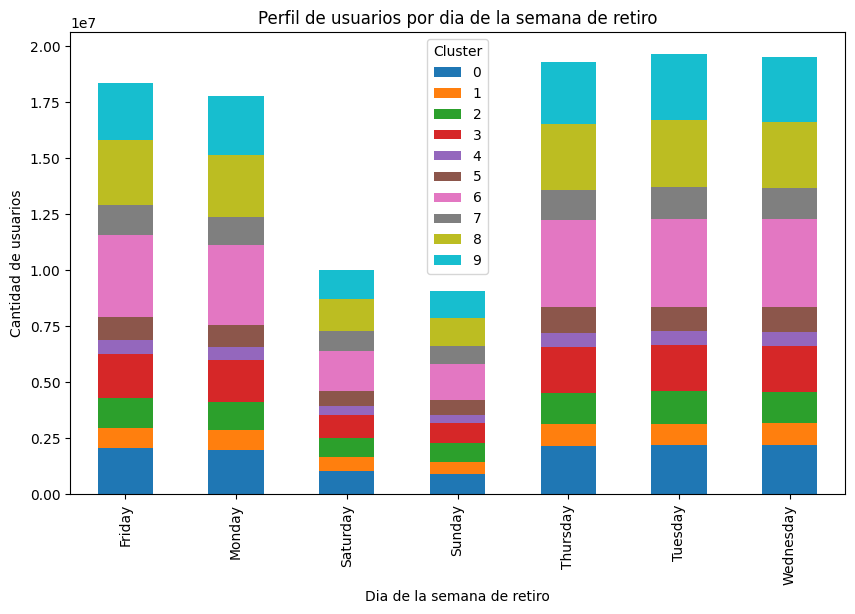

In [21]:
perfil_dia_R.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Perfil de usuarios por dia de la semana de retiro')
plt.xlabel('Dia de la semana de retiro')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Cluster')
plt.show()

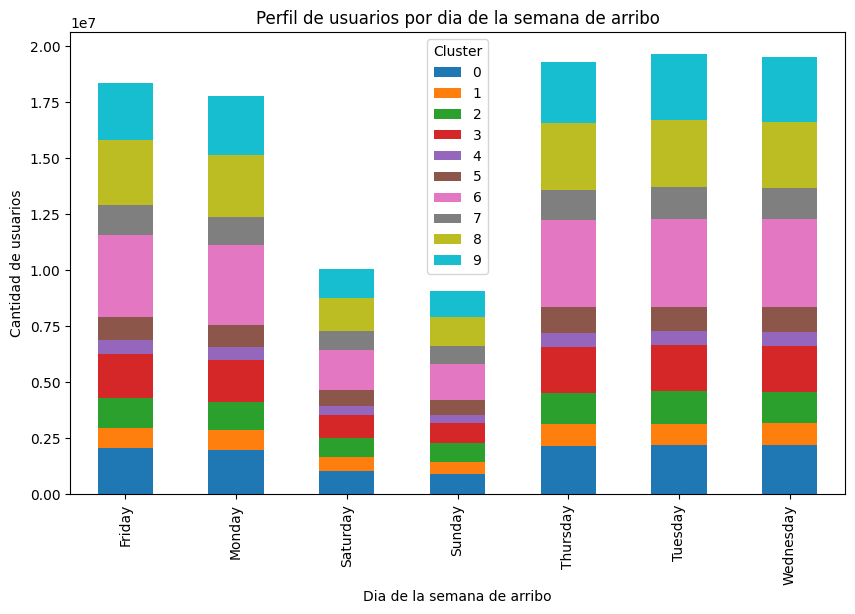

In [22]:
perfil_dia_A.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Perfil de usuarios por dia de la semana de arribo')
plt.xlabel('Dia de la semana de arribo')
plt.ylabel('Cantidad de usuarios')
plt.legend(title='Cluster')
plt.show()

El perfilamineto no fue el adecuado ya que no se encontro estrategia en la que se viera categorias que estuvieran mas presentes por lo que seria posible reenplantearse la cantidad de clusters elegidos